### EDA on cancer-risk-factors

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"data/cancer-risk-factors.csv")
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [8]:
## data understanding

def data_understanding(df):
    print("Dataframe shape:", df.shape)
    print("\nDataframe info:") 
    print(df.info())
    print("\nDataframe description:")
    print(df.describe())
    print("\nDatatypes of each columns:")
    print(df.dtypes)

data_understanding(df)

Dataframe shape: (2000, 21)

Dataframe info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   str    
 1   Cancer_Type              2000 non-null   str    
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int

In [9]:
## data checking

def checking_data(df):
    print("Checking for missing values:")
    print(df.isnull().sum())
    print("\nChecking for duplicate rows:")
    print(df.duplicated().sum())
    print("\nChecking for unique values in each column:")
    print(df.nunique())

checking_data(df)

Checking for missing values:
Patient_ID                 0
Cancer_Type                0
Age                        0
Gender                     0
Smoking                    0
Alcohol_Use                0
Obesity                    0
Family_History             0
Diet_Red_Meat              0
Diet_Salted_Processed      0
Fruit_Veg_Intake           0
Physical_Activity          0
Air_Pollution              0
Occupational_Hazards       0
BRCA_Mutation              0
H_Pylori_Infection         0
Calcium_Intake             0
Overall_Risk_Score         0
BMI                        0
Physical_Activity_Level    0
Risk_Level                 0
dtype: int64

Checking for duplicate rows:
0

Checking for unique values in each column:
Patient_ID                 2000
Cancer_Type                   5
Age                          61
Gender                        2
Smoking                      11
Alcohol_Use                  11
Obesity                      11
Family_History                2
Diet_Red_Meat    

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

Patient_ID                 2000
Cancer_Type                   5
Age                          61
Gender                        2
Smoking                      11
Alcohol_Use                  11
Obesity                      11
Family_History                2
Diet_Red_Meat                11
Diet_Salted_Processed        11
Fruit_Veg_Intake             11
Physical_Activity            11
Air_Pollution                11
Occupational_Hazards         11
BRCA_Mutation                 2
H_Pylori_Infection            2
Calcium_Intake               11
Overall_Risk_Score         2000
BMI                         208
Physical_Activity_Level      11
Risk_Level                    3
dtype: int64

In [31]:
## Understanding the data

df['Risk_Level'].value_counts()

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64

<Axes: xlabel='Risk_Level'>

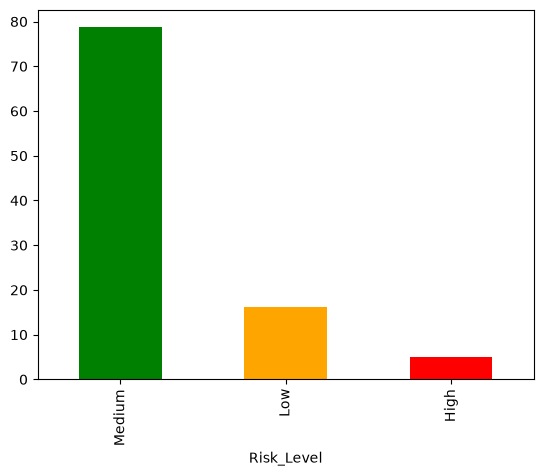

In [32]:
percentages = df['Risk_Level'].value_counts()/len(df)*100
percentages.plot(kind='bar', color=['green', 'orange', 'red'])

## The data is highly imbalanced
- Low -> 16.2%
- Medium -> 78.7%
- High -> 5.1%

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   str    
 1   Cancer_Type              2000 non-null   str    
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation            2000 non-n

In [34]:
df['Cancer_Type'].value_counts()

Cancer_Type
Lung        527
Breast      460
Colon       418
Prostate    305
Skin        290
Name: count, dtype: int64

In [35]:
df['Gender'].value_counts()

Gender
0    1022
1     978
Name: count, dtype: int64

In [37]:
gender_cancer_counts = df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name = "Patients_counts")
gender_cancer_counts['Gender'] = gender_cancer_counts['Gender'].map({0:'Female', 1:'Male'})
print(gender_cancer_counts)

   Gender Cancer_Type  Patients_counts
0  Female      Breast              455
1  Female       Colon              197
2  Female        Lung              238
3  Female        Skin              132
4    Male      Breast                5
5    Male       Colon              221
6    Male        Lung              289
7    Male    Prostate              305
8    Male        Skin              158


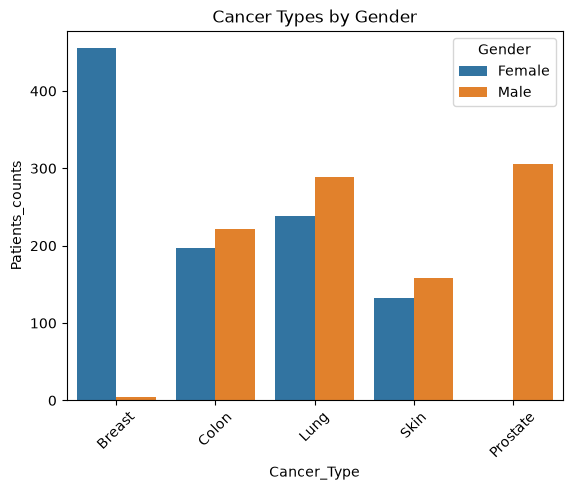

In [40]:
sns.barplot(data = gender_cancer_counts, x = "Cancer_Type", y = "Patients_counts", hue = "Gender")
plt.title('Cancer Types by Gender')
plt.xticks(rotation = 45)
plt.show()

In [41]:
young_age = df[df['Age']<35]
young_age

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
420,BR0020,Skin,32,0,1,3,8,0,5,1,...,0,4,4,0,0,3,0.283988,34.2,1,Low
433,BR0033,Lung,25,0,8,6,5,0,3,5,...,5,8,9,0,0,3,0.550154,28.9,8,Medium
454,BR0054,Lung,29,0,8,6,7,0,3,0,...,0,7,2,0,0,2,0.412898,23.9,6,Medium
468,BR0068,Lung,32,0,8,2,0,0,1,9,...,0,8,2,0,0,2,0.338060,23.9,2,Medium
495,BR0095,Breast,31,0,1,9,10,0,8,5,...,4,0,4,0,0,0,0.421680,28.2,6,Medium
585,BR0185,Lung,34,0,6,8,5,0,3,1,...,3,8,4,0,1,2,0.516405,27.0,3,Medium
593,BR0193,Breast,34,0,5,1,10,1,1,8,...,5,4,5,1,0,4,0.468496,27.3,0,Medium
621,BR0221,Lung,25,0,7,10,6,0,2,7,...,4,7,10,0,0,0,0.583443,27.9,4,Medium
698,BR0298,Lung,34,0,8,0,2,0,0,0,...,1,7,5,0,1,1,0.246356,29.7,9,Low


In [42]:
count_young = (df['Age']<35).sum()
print(f"Number of patients under 35 : {count_young}")

Number of patients under 35 : 9


In [45]:
young_cancer_type = young_age['Cancer_Type'].value_counts()
print(f"Number of patients under 35 by cancer type : {young_cancer_type}")

Number of patients under 35 by cancer type : Cancer_Type
Lung      6
Breast    2
Skin      1
Name: count, dtype: int64


In [5]:
## Finding out which factors highly contribute to high risk level

# Select only the numeric columns for correlation analysis
numeric_df = df.select_dtypes(include = 'number').columns

# Compute the mean of each numeric feature per risk level
risk_means = df[numeric_df].groupby(df['Risk_Level']).mean()

print("Mean values of numeric features by risk level:")
print(risk_means)

Mean values of numeric features by risk level:
                  Age    Gender   Smoking  Alcohol_Use   Obesity  \
Risk_Level                                                         
High        63.745098  0.509804  7.519608     7.519608  7.274510   
Low         63.685185  0.493827  2.845679     2.984568  4.824074   
Medium      63.125794  0.486658  5.479670     5.296061  6.118170   

            Family_History  Diet_Red_Meat  Diet_Salted_Processed  \
Risk_Level                                                         
High              0.205882       7.362745               7.039216   
Low               0.138889       3.972222               2.888889   
Medium            0.205210       5.299238               4.747776   

            Fruit_Veg_Intake  Physical_Activity  Air_Pollution  \
Risk_Level                                                       
High                3.911765           4.921569       8.539216   
Low                 5.666667           3.669753       2.947531   
Medium 


## Key Insights: Risk Factors by Risk Level

### High-Risk Patients Show:
- **Highest Smoking & Alcohol Use**: 7.52 (vs 2.85 & 2.98 for Low-risk)
- **Highest Obesity Level**: 7.27 (vs 4.82 for Low-risk)
- **Elevated Air Pollution Exposure**: 8.54 (vs 2.95 for Low-risk)
- **Lowest Fruit & Vegetable Intake**: 3.91 (vs 5.67 for Low-risk)
- **Highest Overall Risk Score**: 0.70

### Low-Risk Patients Show:
- **Lowest Smoking & Alcohol Use**: 2.85 & 2.98
- **Lowest Air Pollution Exposure**: 2.95
- **Highest Fruit & Vegetable Intake**: 5.67
- **Lowest Obesity Level**: 4.82
- **Lowest Overall Risk Score**: 0.27

### Key Takeaway:
Lifestyle factors (smoking, alcohol use, obesity, diet, and air pollution) are the strongest differentiators between high-risk and low-risk patients, while age and gender have minimal variation across risk levels.


In [7]:
## Focus on difference between high risk and low risk patients

risk_diff = risk_means.loc['High'] - risk_means.loc['Low']
print("Difference in mean values between high risk and low risk patients:")
print(risk_diff)

Difference in mean values between high risk and low risk patients:
Age                        0.059913
Gender                     0.015977
Smoking                    4.673929
Alcohol_Use                4.535040
Obesity                    2.450436
Family_History             0.066993
Diet_Red_Meat              3.390523
Diet_Salted_Processed      4.150327
Fruit_Veg_Intake          -1.754902
Physical_Activity          1.251816
Air_Pollution              5.591685
Occupational_Hazards       3.625999
BRCA_Mutation              0.011983
H_Pylori_Infection         0.069172
Calcium_Intake             0.672295
Overall_Risk_Score         0.430533
BMI                        0.410984
Physical_Activity_Level    0.337509
dtype: float64


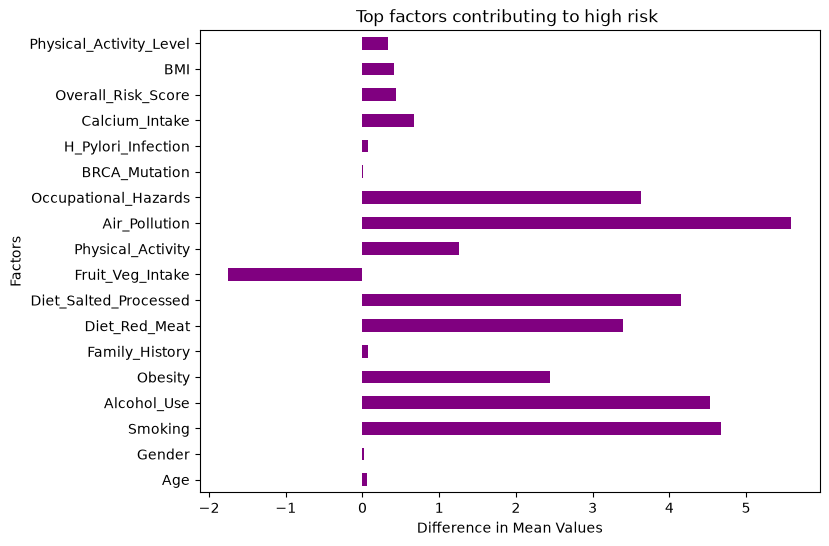

In [9]:
risk_diff.plot(kind='barh', color='purple', figsize=(8, 6), title = "Top factors contributing to high risk ")
plt.xlabel("Difference in Mean Values")
plt.ylabel("Factors")
plt.show()

In [10]:
bmi_by_risk_level = df['BMI'].groupby(df['Risk_Level']).mean()
print("Mean BMI by risk level:")    
print(bmi_by_risk_level)

Mean BMI by risk level:
Risk_Level
High      26.225490
Low       25.814506
Medium    26.256544
Name: BMI, dtype: float64


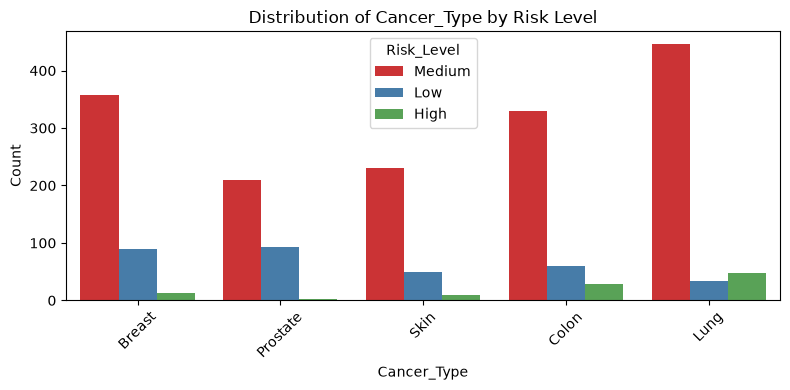

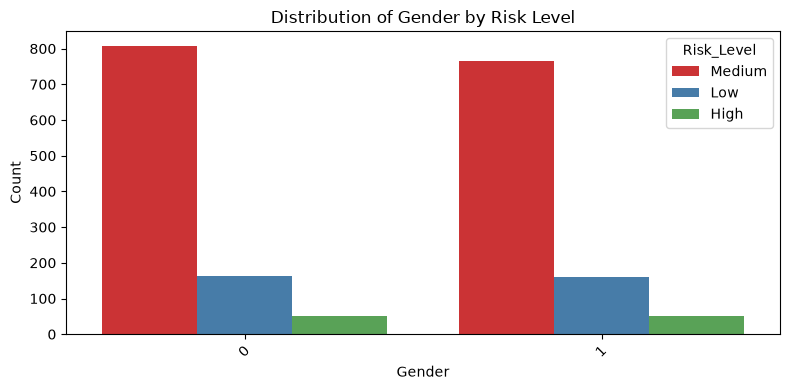

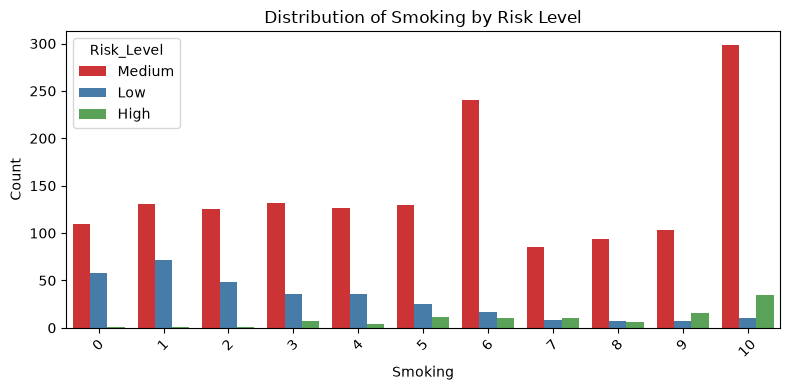

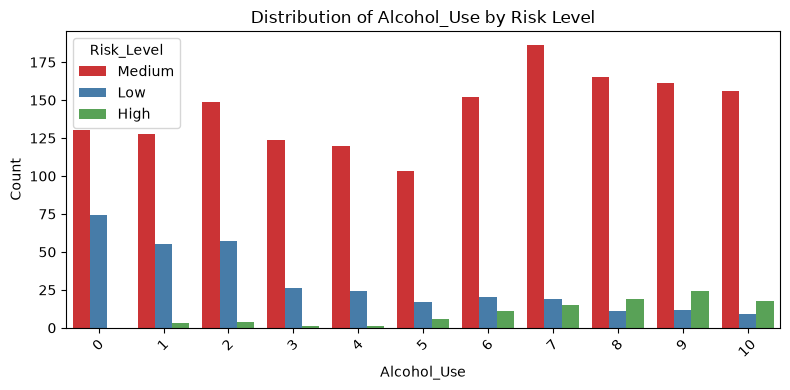

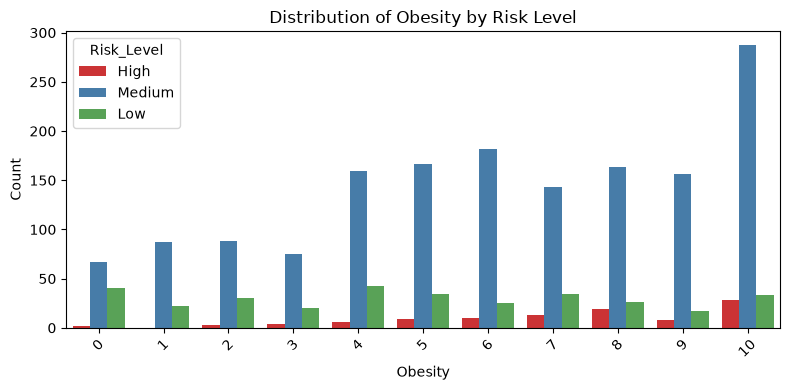

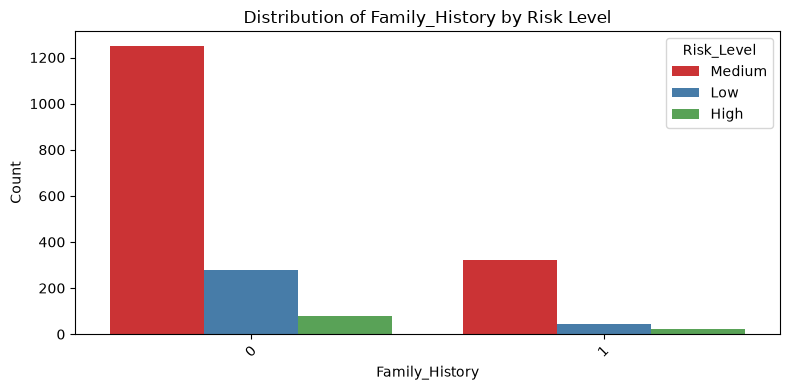

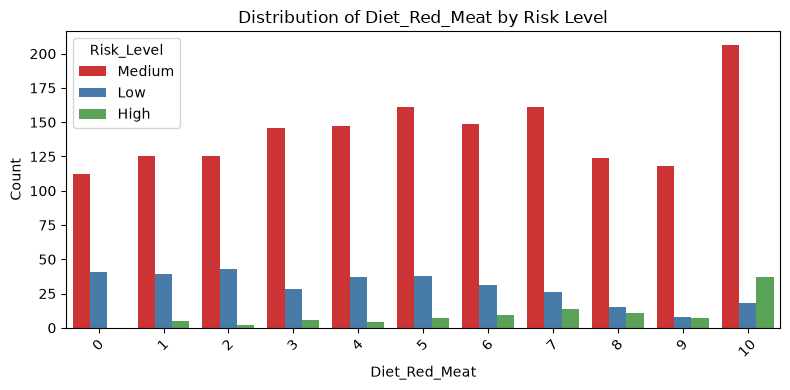

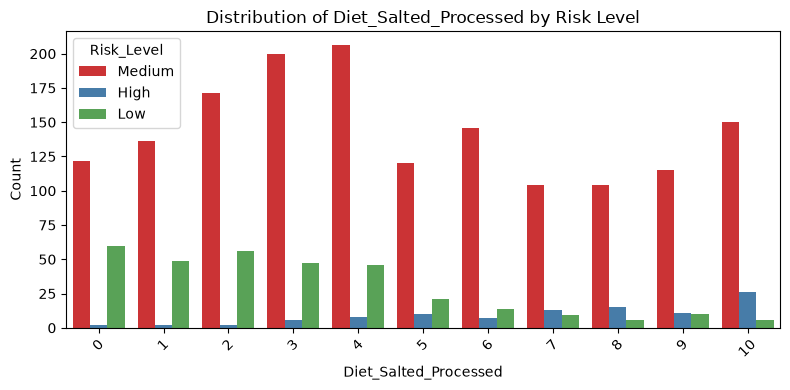

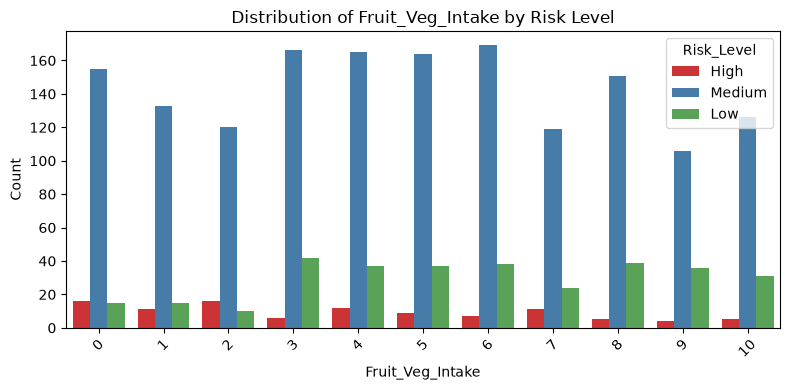

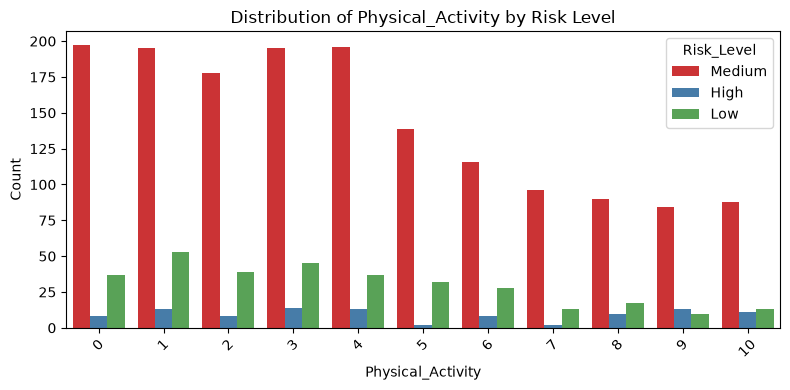

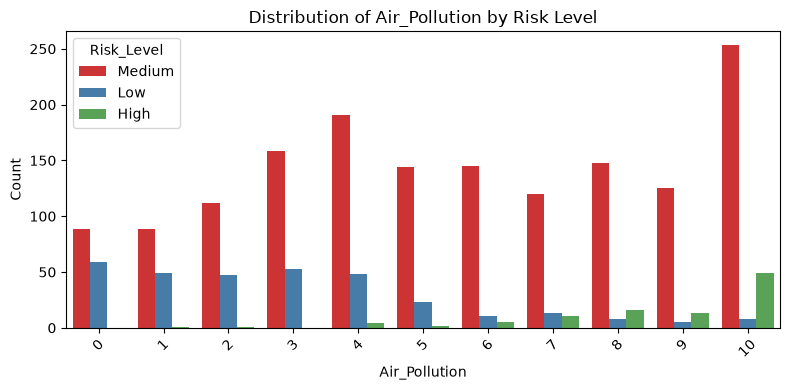

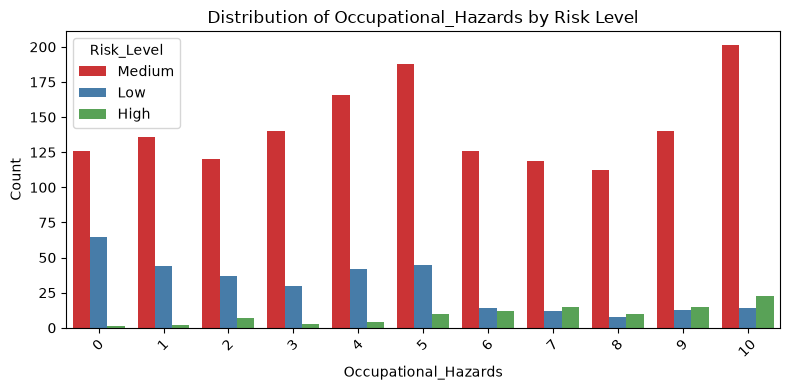

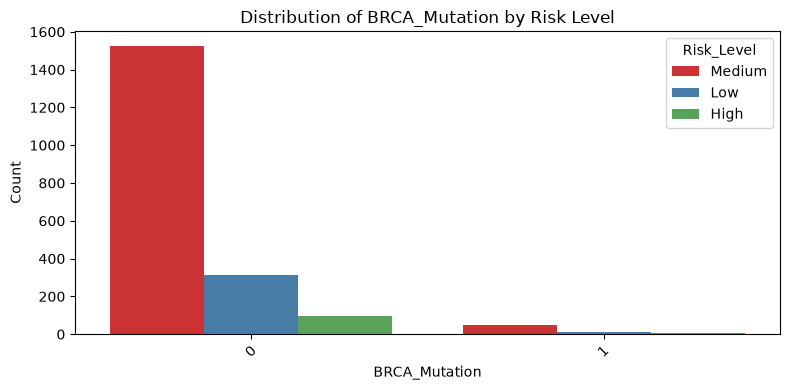

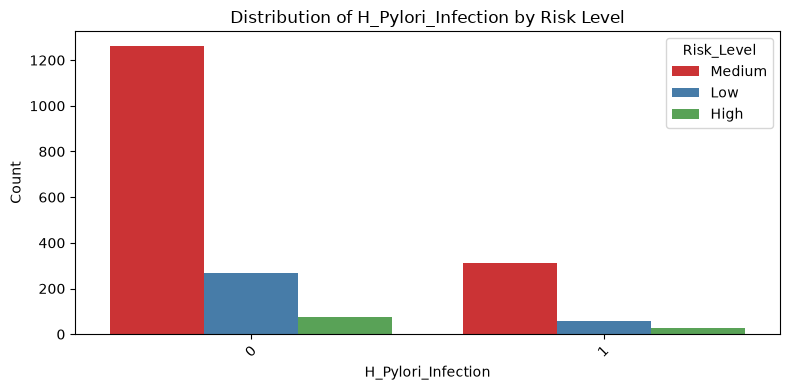

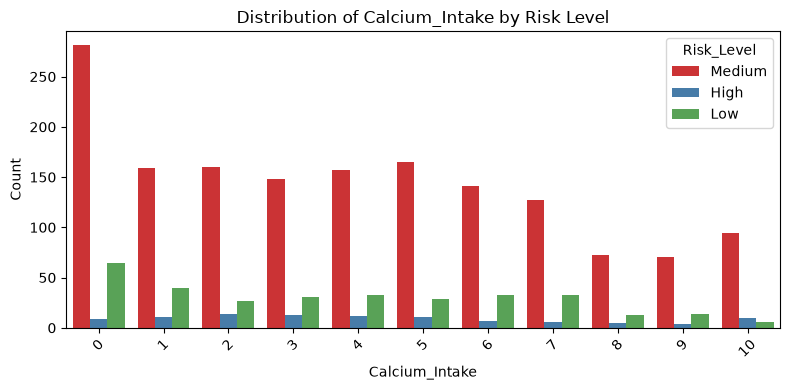

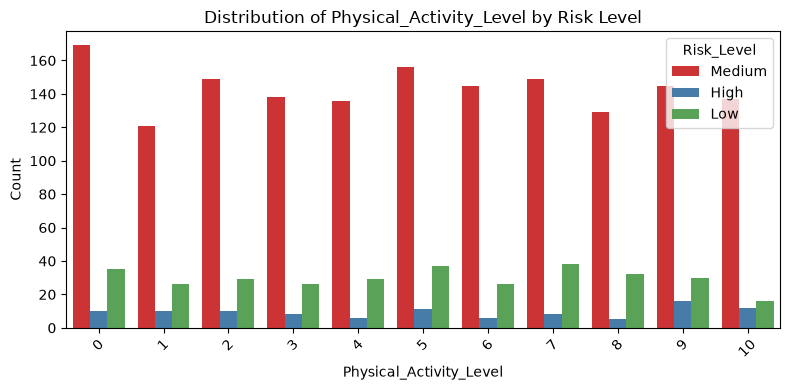

In [15]:
## Univariate analysis

predictors = df.drop(
    columns=['Patient_ID', 'Risk_Level', 'Age', 'Overall_Risk_Score', 'BMI']
).columns

for predictor in predictors:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        x=predictor,
        hue='Risk_Level',
        palette='Set1'
    )
    plt.title(f'Distribution of {predictor} by Risk Level')
    plt.xlabel(predictor)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
df = df.drop(columns=['Patient_ID'])

In [17]:
df['Risk_Level'] = df['Risk_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

In [18]:
df_dummies = pd.get_dummies(df)
df_dummies.head()

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,...,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level,Cancer_Type_Breast,Cancer_Type_Colon,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,68,0,7,2,8,0,5,3,7,4,...,0,0.398696,28.0,5,1,True,False,False,False,False
1,74,1,8,9,8,0,0,3,7,1,...,5,0.424299,25.4,9,1,False,False,False,True,False
2,55,1,7,10,7,0,3,3,4,1,...,6,0.605082,28.6,2,1,False,False,False,False,True
3,61,0,6,2,2,0,6,2,4,6,...,8,0.318449,32.1,7,0,False,True,False,False,False
4,67,1,10,7,4,0,6,3,10,9,...,5,0.524358,25.1,2,1,False,False,True,False,False


<Axes: >

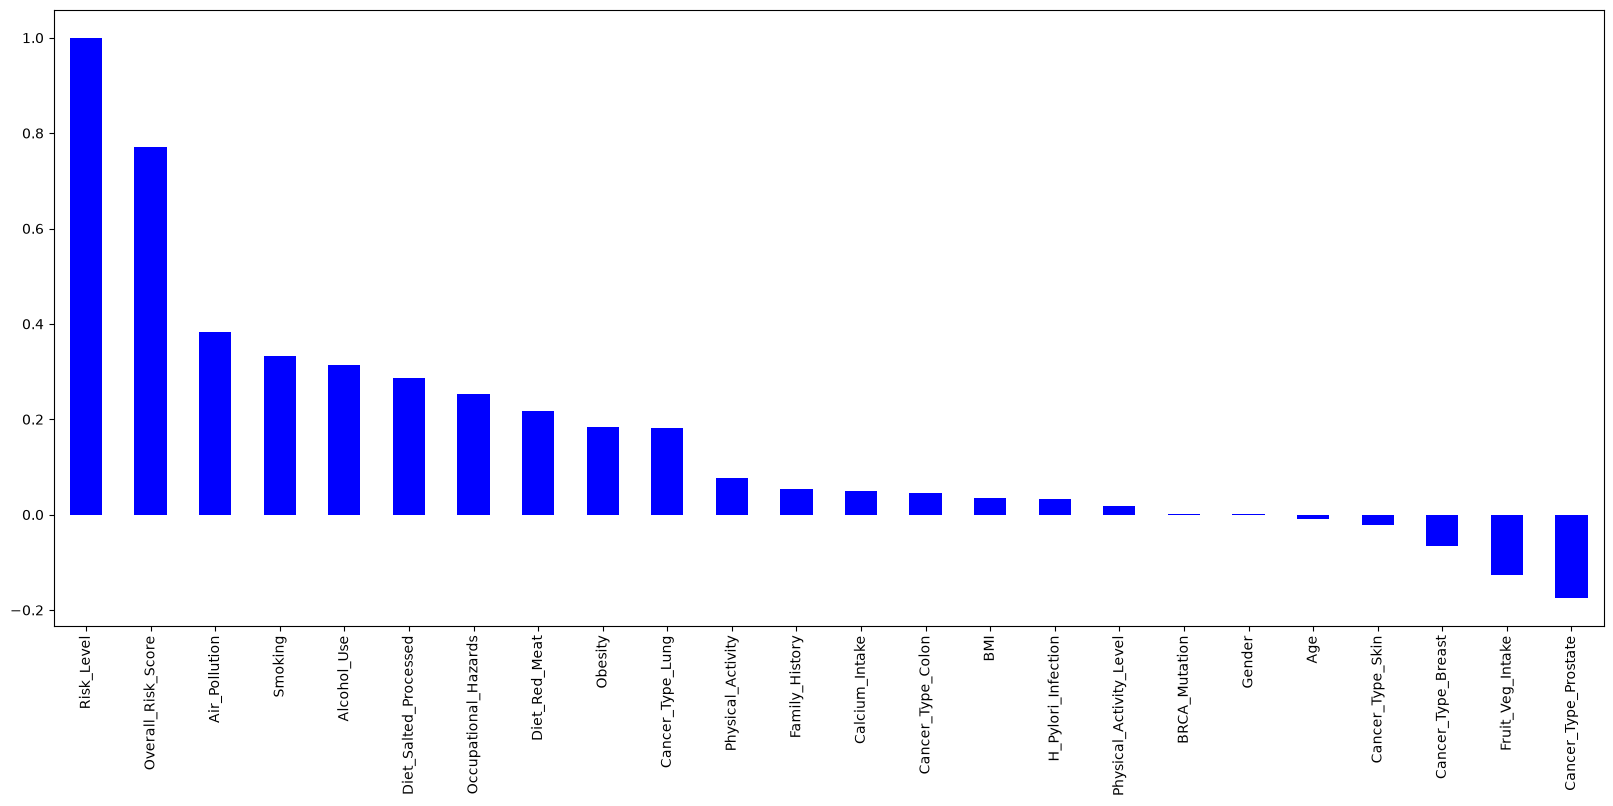

In [19]:
plt.figure(figsize=(20, 8))
df_dummies.corr()['Risk_Level'].sort_values(ascending=False).plot(kind='bar', color='blue')

In [4]:
df.to_csv('cancer-risk-factors-processed.csv', index=False)